# ISM Cloud Identification — Dust Extinction, HI/CO Cubes and NenuFAR Beams

## Purpose
This notebook combines the preparation, visualisation and comparison of:

- 3D dust extinction maps (Edenhofer et al. 2023) along and around a target line of sight;
- HI and CO position–position–velocity (PPV) spectral cubes;
- NenuFAR field-of-view / beam footprints at different frequencies;
- several offset lines of sight around the primary target.

## How to adapt this notebook to your source
All source-specific parameters are grouped in **Section 1 — Configuration**.  
Edit **only that section** to point the analysis at a different target.

## Dependencies

**Local modules**
- `spectral_tools.maps` — dust map queries, beam computation, map loading
- `spectral_tools.tools` — coordinate conversions (`galactic_to_cartesian`, `cartesian_to_galactic`)
- `spectral_tools.graphics` — axis styling helpers
- `spectral_tools.reid19_rotcurve` — Reid et al. (2019) Galactic rotation curve

**Python packages**
- `numpy`, `scipy` (signal, interpolate) — numerics
- `pandas` — tabular data (observation log, source info)
- `dask`, `xarray` — lazy/labelled array handling for PPV cubes
- `matplotlib` (+ `mpl_toolkits`) — 2-D plots
- `plotly` — interactive 3-D plots
- `kaleido` — static export of Plotly figures (PNG/PDF/SVG)
- `scikit-image` (`skimage.measure`) — marching-cubes isosurface extraction
- `astropy` — sky coordinates, units, time
- `nenupy` — NenuFAR beam simulation and angular resolution

**Data files**
- Edenhofer et al. (2023) 3-D dust map (fetched via `maps.DustMap`)
- HI and CO PPV cubes (FITS)
- NenuFAR observation log (CSV)
- Source catalogue: `files/source_info.txt`

# 0. Imports and environment setup

In [1]:
%matplotlib widget

# --- Data handling ---
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import dask.array as da
import xarray as xr
from scipy.interpolate import RegularGridInterpolator

# --- Graphic ---
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from skimage.measure import marching_cubes

# --- Astropy ---
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
import astropy.units as u

# --- NenuFAR / nenupy ---
# from nenupy.astro.sky import Sky
from nenupy.astro.target import FixedTarget
# from nenupy.beam.hpxbeam import HpxBeam
from nenupy.instru import NenuFAR #, NenuFAR_Configuration
# from nenupy.instru.nenufar import Polarization
# from nenupy.astro.pointing import Pointing
import nenupy.instru.nenufar as nenufar_core

# --- Local project modules ---
# # Install the package with: pip install -e . (from a terminal window, inside the parent file of the project)
import spectral_tools.reid19_rotcurve as reid19_rotcurve
import spectral_tools.maps as maps
import spectral_tools.tools as tools
import spectral_tools.graphics as graphics


## Global graphics parameters

In [2]:
# Style settings for every figure of the notebooks
graphics.set_style()

# useful for mosaic plots
alphabet = 'abcdefghijklmnopqrstuvwxyz'


---
## 1. Configuration — edit this section for your source

All parameters below are the **only** values you need to change to run the notebook on a different target.  
Everything else (plots, computations, exports) adapts automatically.  
EXCEPTION: The layout of the Xb. (i) figures will need adaptation to fit the number of target.  
*If you want to display several sources at once, treat one as the "Primary target" and the others as "offsets"*

In [27]:
# ============================================================
# 1a. Primary target
# ============================================================

# must match the 'name' column in ../files/source_info.txt
SOURCE_CODENAME = "CYG_A"
SOURCE_NAME = "Cyg A" # Human-readable name 
# Read sky coordinates from source_info file
_src_info = {}
with open('../files/source_info.txt') as _f:
    for _line in _f:
        if _line.startswith('#') or not _line.strip():
            continue
        _parts = _line.split()
        _src_info[_parts[0]] = (_parts[1], _parts[2])

SOURCE_RA, SOURCE_DEC = _src_info[SOURCE_CODENAME]
CoordSource = SkyCoord(ra=SOURCE_RA, dec=SOURCE_DEC)

# Known (or estimated) distance to the source [pc].
# Used as the end-point of lines in the 3D dust visualisation.
SOURCE_DISTANCE_REAL_PC = np.inf
SOURCE_DISTANCE_PC = SOURCE_DISTANCE_REAL_PC if np.isfinite(SOURCE_DISTANCE_REAL_PC) else 2000


In [49]:
# ============================================================
# 1b. Beam size simulation
# ============================================================

### Simulation of the beam of the instrument
mas_to_use = [f"MA00{i}" for i in range(10)] + [f'MA0{i}' for i in range(10,80)]
nenufar_core = NenuFAR()[mas_to_use]

### NenuFAR frequencies for beam-size visualisation [MHz]. Regularly spaced beam == 1/regularly spaced frequencies
BEAM_FREQUENCIES_MHZ = 1/np.linspace(1/85,0.1,9) * u.MHz
BEAM_ANGULAR_RES     = nenufar_core.angular_resolution(frequency=BEAM_FREQUENCIES_MHZ).value


In [28]:
# ============================================================
# 1c. Offset lines of sight
# ============================================================
SOURCE_HAS_OFFS = False
# Each entry is [galactic_longitude_deg, galactic_latitude_deg].
# These are positions near the source used to probe surrounding ISM.
# Add, remove or change entries freely — the rest of the notebook
# will adapt to however many offsets you define here.
#
# Offset labels and plot colours are assigned automatically in order:
#   off_1 → blue, off_2 → green, off_3 → orange, off_4 → red, ...
# (cycle repeats for more than 4 offsets)

OFFSETS_GAL = [
    [181.90999999, -5.83000002],   # off_1
    [183.75863572, -3.75428324],   # off_2
    [183.69200623, -4.93698766],   # off_3  ← reference offset for the 3D plot
    [184.97599442, -6.13300623],   # off_4
]

# Index (0-based) of the offset used as the local reference frame
# in the 3D Cartesian conversion.  Usually the offset closest to the source.
REF_OFFSET_INDEX = 2   # → OFFSETS_GAL[2]

In [29]:
# ============================================================
# 1d. Observation log
# ============================================================
# Path to the CSV file listing your NenuFAR observations of this source.
# Expected columns: 'Année', 'Mois', 'Jour', 'Heure'
# (generated from the LT10 Source_info Google sheet).
OBSLOG_PATH = "../files/Taua-obslog.csv"

# Duration of each observation block [seconds].
OBS_DURATION_SEC = 7200

In [30]:
# ============================================================
# 1e. Spatial and spectral analysis parameters - general
# ============================================================

# Angular extent used for beam footprint / map display [deg].
SKY_EXTENSION_DEG = 5.0

# Field of view passed to the PPV cube crop routines.
FOV = (5 * u.deg, 5 * u.deg)


In [31]:
# ============================================================
# 1f. Source morphology (angular extent on the sky)
# ============================================================
# Set SOURCE_HAS_EXTENT = False for a point source or unknown morphology.
SOURCE_HAS_EXTENT = False

# Full axes of the source ellipse [arcmin] — from SIMBAD or a catalogue.
SOURCE_MAJOR_ARCMIN = 7.0   # major axis [arcmin]
SOURCE_MINOR_ARCMIN = 5.0   # minor axis [arcmin]

# Two ICRS points defining the major-axis direction (e.g. opposite corners
# of the source from SIMBAD).  Used only to compute the orientation angle
# in Galactic coordinates; see Section 2.
SOURCE_CORNER1_RA  = '05h34m43.95s'
SOURCE_CORNER1_DEC = '+21d58m59.97s'
SOURCE_CORNER2_RA  = '05h34m22.79s'
SOURCE_CORNER2_DEC = '+22d03m33.91s'

# Ellipse patch appearance on sky maps.
SOURCE_ELLIPSE_FACECOLOR = 'white'
SOURCE_ELLIPSE_EDGECOLOR = 'black'
SOURCE_ELLIPSE_LINEWIDTH = 1.5

In [32]:
# ============================================================
# 1g. Output file names
# ============================================================
FIG_FMT = ".pdf"
FIG_DIR = "../figures/Cloud-ID/"


---
## 2. Derived coordinates

Build `SkyCoord` objects and Galactic-frame values for all offsets.
These variables are referenced throughout the notebook.

In [57]:
# Galactic coordinates of the primary source.
source_l = CoordSource.galactic.l   # Galactic longitude (Quantity, deg)
source_b = CoordSource.galactic.b   # Galactic latitude  (Quantity, deg)

# Reference offset used as the coordinate origin in the 3D dust plot.
if SOURCE_HAS_OFFS :
    ref_off = OFFSETS_GAL[REF_OFFSET_INDEX]
else :
    ref_off = [source_l.value, source_b.value]
# Build SkyCoord objects for every offset position.
if SOURCE_HAS_OFFS :
    CoordsOff = [
        SkyCoord(l=off[0], b=off[1], unit="deg", frame="galactic")
        for off in OFFSETS_GAL
    ]
else :
    CoordsOff = []

AllCoords = np.concatenate(([CoordSource], CoordsOff))
# Colour palette for offset lines of sight (cycles if more than 4 offsets).
_BASE_COLORS = ["blue", "green", "orange", "red",
                "purple", "brown", "pink", "cyan"]
colors = [_BASE_COLORS[i % len(_BASE_COLORS)] for i in range(len(OFFSETS_GAL))]
allcolors = np.concatenate((['k'], colors))

# ------------------------------------------------------------------
# Source morphology: position angle in Galactic coordinates
# ------------------------------------------------------------------
# arctan2(Δl, Δb) between the two corner points gives the tilt of the
# major axis in the (l, b) plane — the angle expected by Ellipse.

if SOURCE_HAS_EXTENT:
    _corner1 = SkyCoord(ra=SOURCE_CORNER1_RA, dec=SOURCE_CORNER1_DEC)
    _corner2 = SkyCoord(ra=SOURCE_CORNER2_RA, dec=SOURCE_CORNER2_DEC)

    # Longitude and latitude offsets between the two reference points.
    _dl = _corner2.galactic.l.value - _corner1.galactic.l.value
    _db = _corner2.galactic.b.value - _corner1.galactic.b.value
    SOURCE_ANGLE_DEG = np.degrees(np.arctan2(_dl, _db))

    # Convert full axes from arcmin to degrees for the Ellipse patch.
    _major_deg = SOURCE_MAJOR_ARCMIN / 60.0
    _minor_deg = SOURCE_MINOR_ARCMIN / 60.0

    print(f"Source ellipse — major: {SOURCE_MAJOR_ARCMIN:.1f}', "
          f"minor: {SOURCE_MINOR_ARCMIN:.1f}', "
          f"angle: {SOURCE_ANGLE_DEG:.2f}° (Galactic frame)")
else:
    SOURCE_ANGLE_DEG = 0.0
    _major_deg = _minor_deg = 0.0
    print("Source extent disabled — no ellipse will be drawn.")


print(f"Source '{SOURCE_NAME}':  l = {source_l:.4f},  b = {source_b:.4f}")
for i, (coord, off) in enumerate(zip(CoordsOff, OFFSETS_GAL)):
    print(f"  off_{i+1}  l={off[0]:.4f}°  b={off[1]:.4f}°   colour={colors[i]}")


Source extent disabled — no ellipse will be drawn.
Source 'Cyg A':  l = 76.1899 deg,  b = 5.7554 deg


---
## 3. Observation log and NenuFAR beam tracking

Load the observation timestamps and simulate the NenuFAR pointing for beam visualisation.

> *Optional* -- Run only if you have the observation log with the year, month, day and hour of each observation.

In [10]:
# Read the observation log CSV.
# Expected columns: 'Année' (year), 'Mois' (month), 'Jour' (day), 'Heure' (time HH:MM:SS).
obslog = pd.read_csv(OBSLOG_PATH)

# Build ISO-format timestamp strings for astropy.Time.
timestamps = [
    f"{row['Année']}-{row['Mois']}-{row['Jour']} {row['Heure']}"
    for _, row in obslog.iterrows()
]
obs_times = Time(timestamps)

# Observation block duration (TimeDelta object).
dt = TimeDelta(OBS_DURATION_SEC, format="sec")

print(f"Loaded {len(obs_times)} observation timestamps for '{SOURCE_NAME}'.")


### Projection of the ellipsoid beams in the sky. We take the mean beam over polarisation and time
EVERYBEAM = maps.compute_beams([CoordSource.galactic] + CoordsOff, SKY_EXTENSION_DEG, obs_times, BEAM_FREQUENCIES_MHZ)
print("Generation of real beams: done.")

Loaded 42 observation timestamps for 'Cas A'.


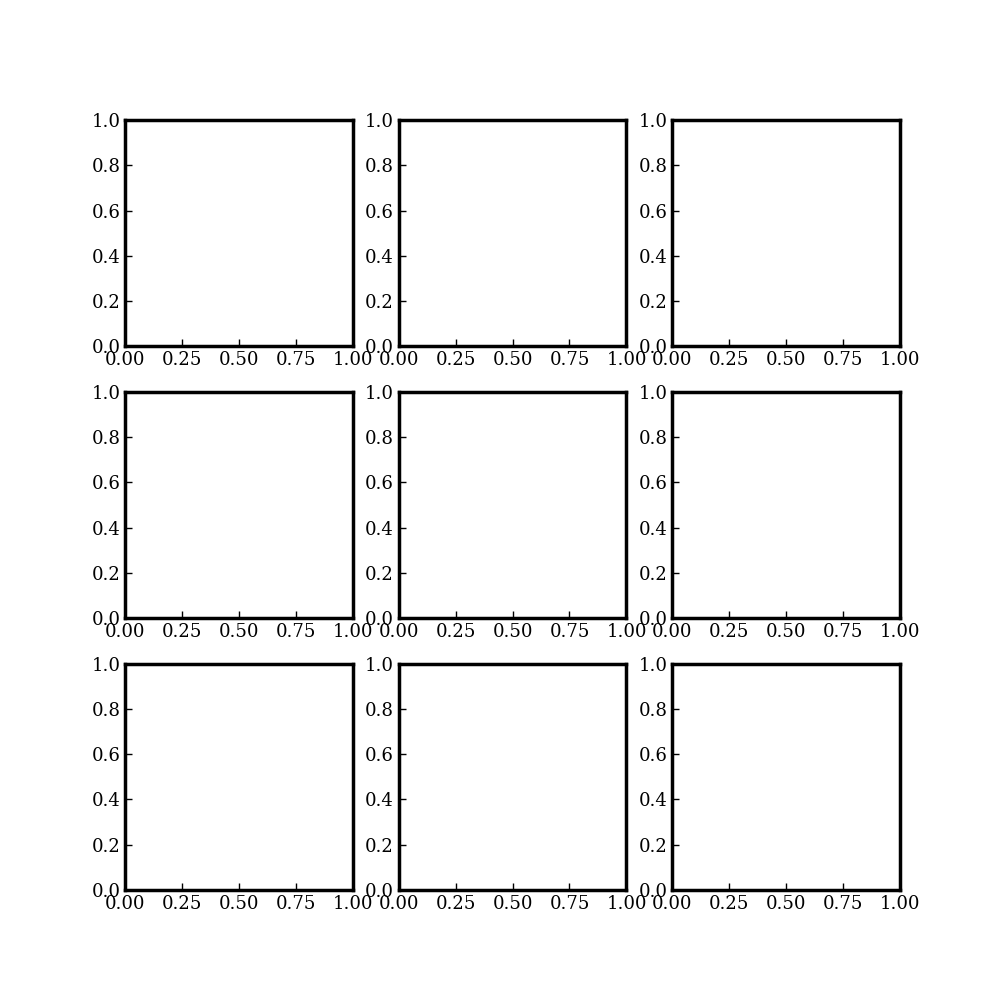

In [12]:
### visualise beams for CoordSource
figbeamsource = plt.figure(figsize=(10,10))
axbeamsource = figbeamsource.subplots(3,3)

axes = axbeamsource.flatten()

In [13]:
BEAMSOURCE = EVERYBEAM[0]
extension = BEAMSOURCE.extension
img_extent = (BEAMSOURCE.center_l[0]-extension, BEAMSOURCE.center_l[0]+extension,
              BEAMSOURCE.center_b[0]-extension, BEAMSOURCE.center_b[0]+extension)
for i in range(len(BEAM_ANGULAR_RES)):
    ax = axes[i]
    ax.clear()    
    ax.imshow(BEAMSOURCE[i].values, extent = img_extent,origin='lower')
    ax.text(0.01,0.95, f"{BEAM_FREQUENCIES_MHZ[i].value : .1f} MHz\n {BEAM_ANGULAR_RES[i]:.2f} °", 
            color="w", va='top', ha='left',
            transform = ax.transAxes)

---
## 4. Dust extinction profiles

Query the Edenhofer et al. (2023) 3-D dust map along the line of sight to the source
and to each offset position.  The result is a 1-D extinction profile as a function of
heliocentric distance.

In [34]:
# ============================================================
# Spatial and spectral analysis parameters - dust
# ============================================================
TRACER = "dust"
# Distance range for dust extinction profiles [kpc].
DUST_R_MIN, DUST_R_MAX, DUST_DR = 0.03, 2.0, 0.01

# Angular resolution of the spatial grid used for extinction profiles [deg].
DUST_DELTA_DEG = 0.1 * u.deg

# Resolution of the spatial grid used for 3D plots [pc].
# The spatial extent of the grid was computed as to include the largest beam of NenuFAR
DUST_X_MIN, DUST_X_MAX, DUST_DX = -2000, 2000, 10
DUST_Y_MIN, DUST_Y_MAX, DUST_DY = -2000, 2000, 10
DUST_Z_MIN, DUST_Z_MAX, DUST_DZ = -500,  500,  10

# Distance axis used for extinction profiles [kpc, as a plain array].
radiitot = np.arange(DUST_R_MIN, DUST_R_MAX, DUST_DR)   # shape (n_radii,)


In [35]:
# Initialise the dust map interpolator (lazy — loads on first query).
# If the map has never been downloaded, run: maps.DustMap.fetch()
dustmap = maps.DustMap()


In [36]:
# Compute the spatially-averaged extinction profile towards the primary source.
# fov and delta define the angular averaging window around the line of sight.
fov_dust = (SKY_EXTENSION_DEG * u.deg, SKY_EXTENSION_DEG * u.deg)

EXTINC_source_los = dustmap.extinction_los(
    CoordSource,
    fov=fov_dust,
    delta=DUST_DELTA_DEG,
    r_min=DUST_R_MIN,
    r_max=DUST_R_MAX,
    dr=DUST_DR
)
# EXTINC_source_los: 1-D array, shape (n_radii,), same length as radiitot.

# Also compute profiles for each offset line of sight.
EXTINC_offs_los = []
for i, coord in enumerate(CoordsOff):
    ext = dustmap.extinction_los(
        coord,
        fov=fov_dust,
        delta=DUST_DELTA_DEG,
        r_min=DUST_R_MIN,
        r_max=DUST_R_MAX,
        dr=DUST_DR
    )
    EXTINC_offs_los.append(ext)
    print(f"off_{i+1} done — peak extinction at {radiitot[np.argmax(ext)]:.2f} kpc")


Dust extinction (LOS): 100%|█████████████████| 197/197 [00:01<00:00, 115.45it/s]


---
### 4a. 3D dust visualisation

Build a 3-D isosurface of the dust density around the source using the marching-cubes
algorithm, then overlay the lines of sight in Galactic Cartesian coordinates.

In [37]:
# Build a 3-D dust density cube in Galactic Cartesian coordinates [pc].
# The grid is defined in (x, y, z) pc; each point is converted back to
# (l, b, r) to query the dust map, so the marching-cubes output is already
# in pc on all three axes.
#
# Cartesian frame: Sun at origin, standard Galactic Cartesian (X toward l=0, Y toward l=90, Z north).
#
# Grid resolution: decrease the step sizes for finer detail (slower).

# 1-D axes of the Cartesian grid.
x_arr = np.arange(DUST_X_MIN, DUST_X_MAX, DUST_DX)  # radial distance [pc]
y_arr = np.arange(DUST_Y_MIN, DUST_Y_MAX, DUST_DY)  # transverse [pc]
z_arr = np.arange(DUST_Z_MIN, DUST_Z_MAX, DUST_DZ)  # vertical   [pc]

# 3-D meshgrid of Cartesian coordinates.
x_grid, y_grid, z_grid = np.meshgrid(x_arr, y_arr, z_arr, indexing='ij')

# Convert each Cartesian point to Galactic (l, b, r) for the dust query.
l_center, b_center = 0, 0   # standard Galactic Cartesian frame
l_grid, b_grid, r_grid = tools.cartesian_to_galactic(x_grid, y_grid, z_grid, l_center, b_center)

# Beam mask: compute angular separation from source before querying — skip voxels outside the cone.
_l_s = np.radians(source_l.value)
_b_s = np.radians(source_b.value)
_sep = np.degrees(np.arccos(np.clip(
    np.sin(np.radians(b_grid)) * np.sin(_b_s) +
    np.cos(np.radians(b_grid)) * np.cos(_b_s) * np.cos(np.radians(l_grid) - _l_s),
    -1, 1
)))
beam_mask = _sep <= SKY_EXTENSION_DEG
print(f"Querying {beam_mask.sum()} / {beam_mask.size} voxels ({100*beam_mask.mean():.1f} % of grid)")

# Query the dust map only for voxels inside the cone; fill the rest with 0.
values = np.zeros_like(r_grid)
coords_in_beam = SkyCoord(
    l=l_grid[beam_mask] * u.deg,
    b=b_grid[beam_mask] * u.deg,
    frame='galactic',
    distance=r_grid[beam_mask] * u.pc
)
shell = dustmap._query.query(coords_in_beam)
values[beam_mask] = np.where(np.isnan(shell), 0.0, shell)

# Voxel sizes for marching_cubes (uniform grid).
dx, dy, dz = DUST_DX, DUST_DY, DUST_DZ
x0, y0, z0 = x_arr[0], y_arr[0], z_arr[0]

Querying 70623 / 16000000 voxels (0.4 % of grid)


In [38]:
# -----------------------------------------------------------------
# Isosurface extraction using the marching-cubes algorithm.
# The threshold is set to 1 % of the peak density — adjust if needed.
# -----------------------------------------------------------------
threshold = np.max(values) / 100
print(f"Isosurface threshold: {threshold:.5g}")

verts, faces, normals, vals = measure.marching_cubes(
    values,
    level=threshold,
    spacing=(dx, dy, dz)
)
# Shift vertices back to physical (Galactic) coordinates.
verts[:, 0] += x0
verts[:, 1] += y0
verts[:, 2] += z0



Isosurface threshold: 0.00011783


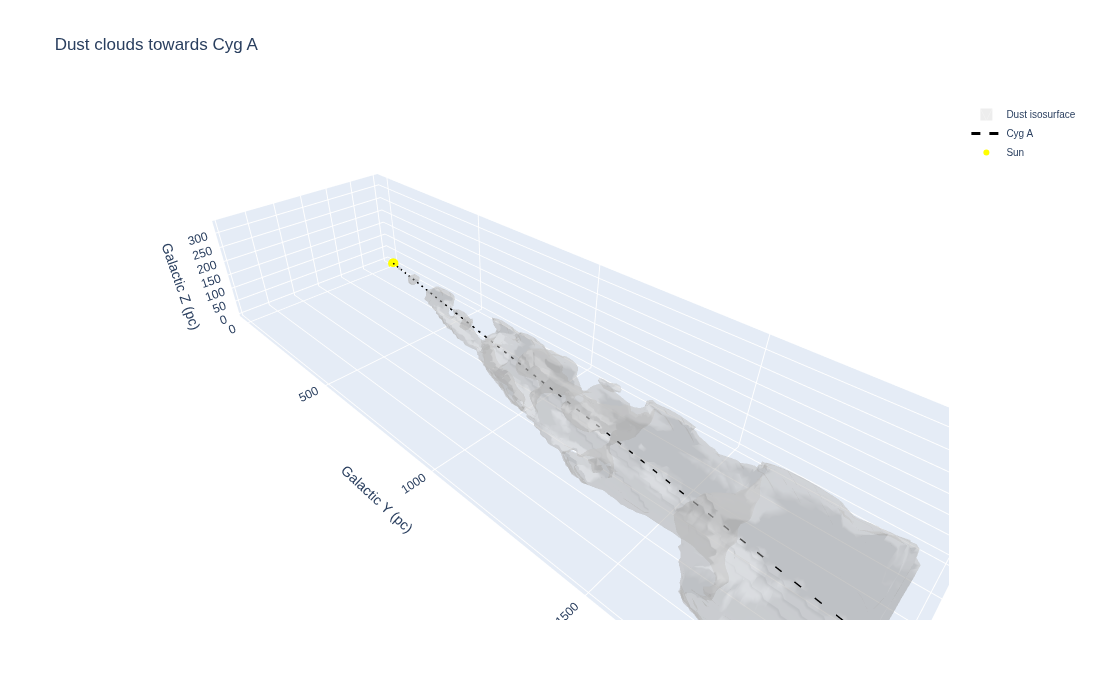

In [39]:
# -----------------------------------------------------------------
# 3-D plot: isosurface + lines of sight.
# -----------------------------------------------------------------
fig_dust = go.Figure()

fig_dust.add_trace(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    opacity=0.4,
    color="lightgray",
    name="Dust isosurface",
    showlegend=True,
))

# ── Lines of sight (offsets) ──────────────────────────────────────────────────

if SOURCE_HAS_OFFS :
    for i, off in enumerate(OFFSETS_GAL):
        xc, yc, zc = tools.galactic_to_cartesian(
            SOURCE_DISTANCE_PC, off[0], off[1], ref_off[0], ref_off[1]
        )
        fig_dust.add_trace(go.Scatter3d(
            x=[0, xc], y=[0, yc], z=[0, zc],
            mode="lines",
            line=dict(color=colors[i], dash="dot", width=3),
            name=f"off_{i+1}",
        ))
    
# ── Primary line of sight ─────────────────────────────────────────────────────

xc, yc, zc = tools.galactic_to_cartesian(
    SOURCE_DISTANCE_PC, source_l.value, source_b.value, 0,0,# ref_off[0], ref_off[1]
)
fig_dust.add_trace(go.Scatter3d(
    x=[0, xc], y=[0, yc], z=[0, zc],
    mode="lines",
    line=dict(color="black", dash="dash", width=3),
    name=SOURCE_NAME,
))

# ── Sun marker ───────────────────────────────────────────────────────────────────
fig_dust.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=6, color='yellow', symbol='circle'),
    name='Sun',
))

# ── Layout ────────────────────────────────────────────────────────────────────

x_range = x_arr.max() - x_arr.min()
y_range = y_arr.max() - y_arr.min()
z_range = z_arr.max() - z_arr.min()


fig_dust.update_layout(
    title=f"Dust clouds towards {SOURCE_NAME}",
    height=700,
    scene=dict(
        xaxis=dict(title="Galactic X (pc)"),
        yaxis=dict(title="Galactic Y (pc)"),
        zaxis=dict(title="Galactic Z (pc)"),
        aspectmode="data",

    ),
    legend=dict(font=dict(size=10)),
)



fig_dust.show(config={"responsive":True})

In [40]:
OUTNAME = f"dust3D_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + '.html' # formatting exception: html to still have interactive plot
fig_dust.write_html(FIG_DIR + OUTNAME)
print(f"Saved: {OUTNAME} in {FIG_DIR}")

Saved: dust3D_Cyg_A_dust.html in ../figures/Cloud-ID/


---
### 4b. Cloud path-length estimation from dust profiles

Identify extinction peaks in the line-of-sight profile and measure their
full-width-at-half-maximum (FWHM) as an estimate of each cloud's depth.

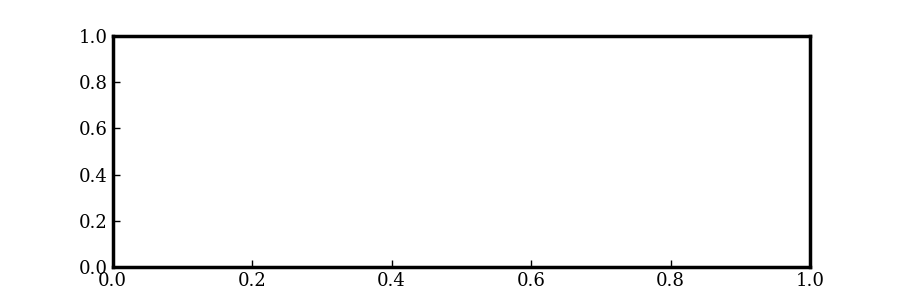

In [31]:
n_panels = 1 + len(OFFSETS_GAL) if SOURCE_HAS_OFFS else 1  # source + one panel per offset
fig_peaks, axes_peaks = plt.subplots(
    n_panels, 1,
    figsize=(9, 3 * n_panels),
    sharex=True
)
if n_panels == 1:
    axes_peaks = [axes_peaks]


In [32]:

# Normalised source extinction profile — used as reference in offset panels.
r_norm = EXTINC_source_los / np.nanmax(EXTINC_source_los)

CLOUD_LEVEL = 0.5 # full width x % max of the peak

for ax in axes_peaks :
    ax.clear()

# --- Panel 0: primary source ---
ax0 = axes_peaks[0]
ax0.plot(radiitot, r_norm, c='black', lw=1.5)
dustmap.get_length_clouds(
    # EXTINC_source_los,
    r_norm,
    r_min=DUST_R_MIN,
    r_max=DUST_R_MAX,
    level=CLOUD_LEVEL,
    ax=ax0,
    colors=['black'],
)
ax0.set_ylabel("Normalised extinction", fontsize=11)
ax0.set_title(f"{SOURCE_NAME} — line of sight", fontsize=11)
ax0.set_ylim(-0.05, 1.3)
graphics.set_axes(ax0)

# --- Panels 1…N: offset lines of sight ---
for k, (ext_off, col) in enumerate(zip(EXTINC_offs_los, colors)):
    ax = axes_peaks[k + 1]
    norm_off = ext_off / np.nanmax(ext_off)

    # Source profile as a gray dashed reference.
    ax.plot(radiitot, r_norm, c='gray', lw=1.0, ls='dashed',
            label=f"{SOURCE_NAME} (ref)")

    # Offset profile with cloud annotations.
    ax.plot(radiitot, norm_off, c=col, lw=1.5)
    dustmap.get_length_clouds(
        # ext_off,
        norm_off,
        r_min=DUST_R_MIN,
        r_max=DUST_R_MAX,
        level=CLOUD_LEVEL,
        ax=ax,
        colors=[col],
    )

    off = OFFSETS_GAL[k]
    ax.set_ylabel("Normalised extinction", fontsize=11)
    ax.set_title(
        f"off_{k+1}  (l = {off[0]:.2f}°,  b = {off[1]:.2f}°)",
        fontsize=11
    )
    ax.set_ylim(-0.05, 1.3)
    ax.legend(fontsize=8, loc='upper right')
    graphics.set_axes(ax)

axes_peaks[-1].set_xlabel("Distance from the Sun (kpc)", fontsize=12)
pct_str = f"FW{round(CLOUD_LEVEL * 100):.0f}M"
fig_peaks.suptitle(
    f"Dust extinction peaks — {SOURCE_NAME}  ({pct_str}, level = {CLOUD_LEVEL})",
    fontsize=13, y=1.01
)
fig_peaks.tight_layout()

In [33]:
OUTNAME = f"dust-LoS_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_peaks.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

Saved: dust-LoS_Cas_A_dust.pdf in ../figures/Cloud-ID/


---
### 4c. Summary table of dust in lines-of-sights

Summarise dust distribution in the different beams based on the dust absorption.
Provides an estimate of the distance of the clouds, as well as their depth based on the FWHM of the absorption.

In [36]:
# Estimate cloud path lengths for the primary source line of sight.
# Optional keyword arguments let you flag noisy peaks or force Gaussian fitting:
#   flags=[k]         — skip peak index k
#   large_peaks=[k]   — double the search radius for peak k
#   small_peaks=[k]   — halve the search radius for peak k
#   fit_gaussian=True — use Gaussian fitting instead of direct FWHM
#   level = x/100     — compute the full width at x % of the maximum of the peak. Default = 0.5

los_names = ["CasA"]
OFFNAMES = []
peak_idx, peak_dist, path_lengths = dustmap.get_length_clouds(
    EXTINC_source_los,
    r_min=DUST_R_MIN * 1000,   # convert kpc → pc for the distance axis
    r_max=DUST_R_MAX * 1000,
    level = 0.5
)

indices_list = [peak_idx]
distances_list = [peak_dist]
sizes_list = [path_lengths]
print(f"Detected {len(peak_idx)} dust cloud(s) towards {SOURCE_NAME}:")
for i, (d, pl) in enumerate(zip(peak_dist, path_lengths)):
    print(f"  Cloud {i+1}: distance = {d:.0f} pc,  path length ≈ {pl:.0f} pc")

for i,sourcename in enumerate(OFFNAMES) :
    peak_idx, peak_dist, path_lengths = dustmap.get_length_clouds(
        EXTINC_offs_los[i],
        r_min=DUST_R_MIN * 1000,   # convert kpc → pc for the distance axis
        r_max=DUST_R_MAX * 1000,
        level = 0.5
    )

    indices_list.append(peak_idx)
    distances_list.append(peak_dist)
    sizes_list.append(path_lengths)
    print(f"Detected {len(peak_idx)} dust cloud(s) towards {sourcename}:")
    for i, (d, pl) in enumerate(zip(peak_dist, path_lengths)):
        print(f"  Cloud {i+1}: distance = {d:.0f} pc,  path length ≈ {pl:.0f} pc")


Detected 10 dust cloud(s) towards Cas A:
  Cloud 1: distance = 70 pc,  path length ≈ 26 pc
  Cloud 2: distance = 181 pc,  path length ≈ 31 pc
  Cloud 3: distance = 291 pc,  path length ≈ 24 pc
  Cloud 4: distance = 362 pc,  path length ≈ 26 pc
  Cloud 5: distance = 663 pc,  path length ≈ 67 pc
  Cloud 6: distance = 834 pc,  path length ≈ 92 pc
  Cloud 7: distance = 995 pc,  path length ≈ 49 pc
  Cloud 8: distance = 1186 pc,  path length ≈ 21 pc
  Cloud 9: distance = 1296 pc,  path length ≈ 76 pc
  Cloud 10: distance = 1809 pc,  path length ≈ 58 pc


In [37]:
#  SUMMARY OF ALL CLOUDS PRESENT ALONG THE LINES OF SIGHT
# Two clouds are considered the same if their distances agree within `tol`
 
TOL = 30  # pc — adjust to your data

allclouds_list = [
    list(zip(distances, sizes))
    for distances, sizes in zip(distances_list, sizes_list)
]

group_reps, all_entries = tools.find_all_groups(keys = los_names, 
                                                values_list = allclouds_list, 
                                                tol=TOL)

sorted_groups = sorted(enumerate(group_reps), key=lambda x: x[1])
rank = {old_i: new_i for new_i, (old_i, _) in enumerate(sorted_groups)}
group_reps_sorted = [r for _, r in sorted_groups]
all_entries = [(los, rank[g], dist, size) for los, g, dist, size in all_entries]
 
n_groups = len(group_reps_sorted)
cloud_labels = [f"Cloud {i+1} ({int(r)} pc)" for i, r in enumerate(group_reps_sorted)]

# ── Presence matrix ───────────────────────────────────────────────────────────
# Cells show the cloud size; empty = absent
 
matrix = pd.DataFrame(
    index   = cloud_labels,
    columns = los_names,
    data    = "",
    dtype   = object,
)
matrix.index.name = "Cloud (distance) \\ Pointing"
 
for los, g, dist, size in all_entries:
    matrix.loc[cloud_labels[g], los] = round(size)
 
display(
    matrix.style.set_caption(
        "Cloud depth (pc) per line of sight"
    )
)



,CasA
Cloud (distance) \ Pointing,
Cloud 1 (70 pc),26
Cloud 2 (180 pc),31
Cloud 3 (291 pc),24
Cloud 4 (361 pc),26
Cloud 5 (663 pc),67
Cloud 6 (834 pc),92
Cloud 7 (994 pc),49
Cloud 8 (1185 pc),21
Cloud 9 (1296 pc),76


---
## 5. HI spectral cube — extraction and moment maps

Load the HI 21-cm PPV cube, crop it around the source, compute the mean spectrum
and moment maps, then compare them to the dust profile and NenuFAR beams.

In [41]:
# ============================================================
# Spatial and spectral analysis parameters - HI
# ============================================================
TRACER = 'HI'
# Velocity range to highlight in HI spectra [km/s].
VMIN_HI, VMAX_HI = -50, 50

# Graphic parameters
HI_color = "red"
HI_cmap = "Reds"

In [42]:
# Initialise the map loader for the current source.
# The loader finds the HI and CO FITS cubes by matching SOURCE_NAME
# against the file names in the data directories.
# Adjust path_co and path_hi if your cubes live elsewhere.
map_loader = maps.MapLoader(
    source=SOURCE_NAME.replace(" ", ""),   # e.g. "TauA" — must match FITS file names
    path_co="../maps/COmaps/",
    path_hi="../maps/HImaps/"
)


In [43]:
# Crop the HI cube to the field of view defined in Section 1.
# Returns:
#   SLICEHI      — cropped PPV sub-cube (3-D array)
#   velHI        — velocity axis [km/s]
#   spectrumHI   — mean spectrum over the aperture [K]
#   lonslice_HI  — Galactic longitude axis of the cropped region [deg]
#   latslice_HI  — Galactic latitude axis [deg]
#   mom0_HI      — moment-0 map (integrated intensity) over the full velocity range

SLICEHI, velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_HI = \
    map_loader.crop_square(CoordSource, TRACER, FOV)

print(f"HI cube cropped: {SLICEHI.shape},  vel range [{velHI.min():.1f}, {velHI.max():.1f}] km/s")


VMIN_HI = max(velHI.min(), VMIN_HI)
VMAX_HI = min(velHI.max(), VMAX_HI)

HI cube cropped: (155, 60, 60),  vel range [-99.1, 99.3] km/s


In [44]:
# Compute the moment-0 map restricted to the velocity range [VMIN_HI, VMAX_HI].
# This isolates emission likely associated with ISM clouds along the line of sight.

_, velHI_full, spectrumHI_full, lonHI_full, latHI_full, mom0_HI_vel = \
    map_loader.moment0_crop(
        CoordSource, 'HI', FOV,
        v_start=VMIN_HI, v_stop=VMAX_HI,
        shape="square"
    )

# Velocity condition mask — used later for coloured spectrum segments.
condHI = (velHI >= VMIN_HI) & (velHI <= VMAX_HI)


### 5a. Mosaic channel map
Displays HI brightness temperature in 25 velocity channels arranged in a 5×5 grid.  
Each panel covers a $\displaystyle \frac{VMAX\_HI-VMIN\_HI}{N\_PANELS}$ km/s wide velocity slice.  

In [45]:
# ── Configuration ─────────────────────────────────────────────────────────────

SHAPE     = "square"
EXTEN     = SKY_EXTENSION_DEG        # angular size of each cutout

VMIN_CHAN = VMIN_HI                  # lowest velocity edge (km/s)
VMAX_CHAN = VMAX_HI                  # highest velocity edge (km/s)
N_PANELS  =  25                  # number of panels in the channel map (i.e. resolution of the channel map)

VMIN_NORM = 0                   # colormap minimum (normalised T_b)
VMAX_NORM = np.nanmax(SLICEHI)  # colormap maximum (normalised T_b)

SHOW_BEAM   = False            # overlay the beam FWHM circle
SHOW_SOURCE = True
SHOW_OFFPTS = True             # overlay the off-beam pointing

center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

print("Width of the channel map =", (VMAX_HI-VMIN_HI)/N_PANELS, "km/s")

Width of the channel map = 4.0 km/s


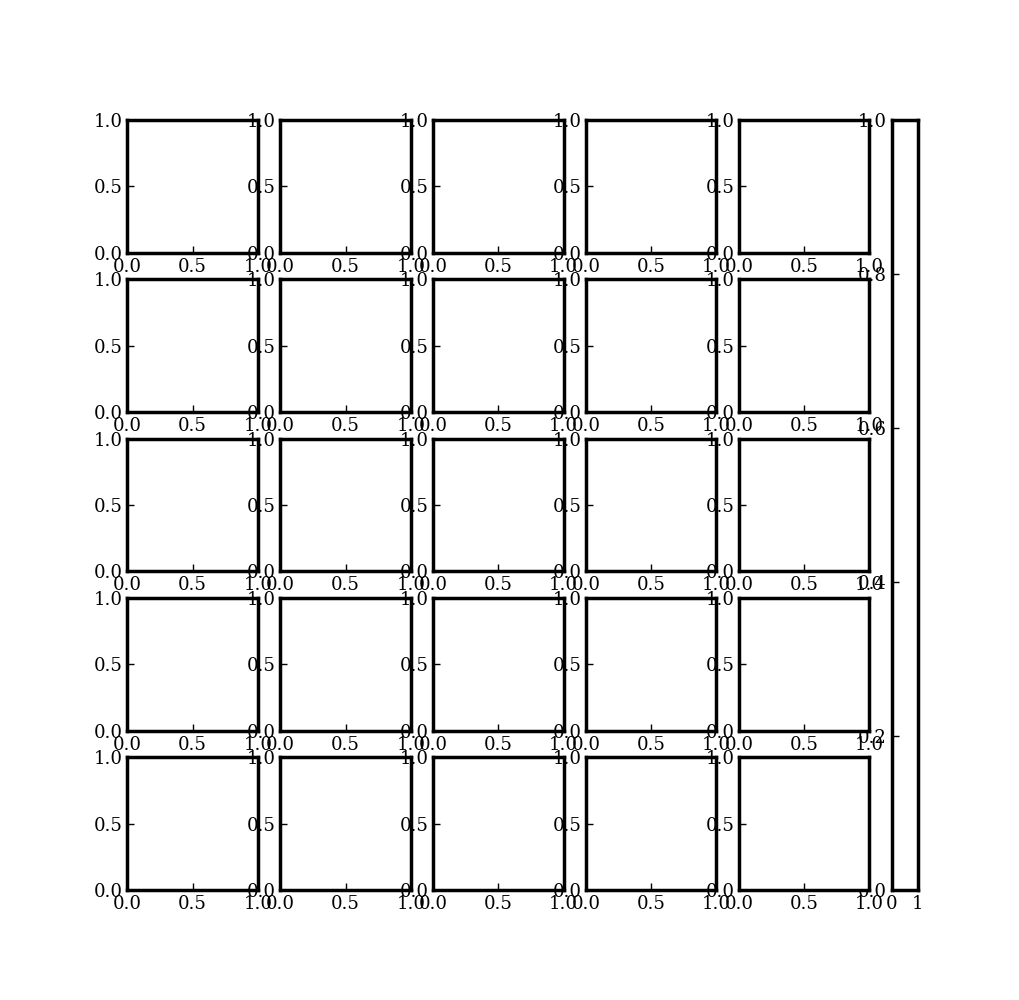

In [25]:
# ============================================================
# Figure initialisation - run next cell to fill
# ============================================================
# 5×5 panels (letters a–y) + 1 narrow column (z) for the colorbar

fig_chanHI = plt.figure(figsize=(10.2, 10))
axes_chan = fig_chanHI.subplot_mosaic(
    """
    abcdez
    fghijz
    klmnoz
    pqrstz
    uvwxyz
    """,
    width_ratios=(1, 1, 1, 1, 1, 0.2),
)

In [46]:
# ── Channel edges ─────────────────────────────────────────────────────────────

chan_edges = np.linspace(VMIN_CHAN, VMAX_CHAN, N_PANELS + 1)  # shape (26,)

# ── Draw one panel per channel ────────────────────────────────────────────────

for i in range(N_PANELS):
    vmin, vmax = chan_edges[i], chan_edges[i + 1]

    # Number of HI spectral pixels falling inside this velocity slice
    # (used to normalise the moment-0 map to a per-channel average)
    

    # Compute the moment-0 map for this slice
    _, _, _, lon, lat, mom0 = map_loader.moment0_crop(
        CoordSource, TRACER, FOV,
        v_start=vmin, v_stop=vmax,
        shape=SHAPE
    )

    # Mask empty pixels so they are transparent
    mom0[mom0 == 0] = np.nan

    # ── Panel ────────────────────────────────────────────────────────────────
    ax = axes_chan[alphabet[i]]
    ax.clear()

    mappable = ax.imshow(
        mom0,
        vmin=VMIN_NORM, vmax=VMAX_NORM,
        extent=(lon[0], lon[-1], lat[0], lat[-1]),
        origin="lower",
        cmap=HI_cmap,
    )

    # Target marker
    ax.plot(center_l, center_b, ".", c="k")

    # Velocity range label
    ax.text(
        0.5, 0.1, f"{vmin:.0f} $-$ {vmax:.0f} km/s",
        color="k", transform=ax.transAxes, ha="center", fontsize=10,
    )

    # Beam FWHM circle (dashed) 
    # Here we use the widest beam, approximated to a circle 
    # see later for more accurate beam representation
    if SHOW_BEAM:
        beam_radius = 3.59 / 2  # degrees
        ax.add_patch(Circle(
            xy=(center_l.value, center_b.value),
            radius=beam_radius,
            fill=False,
            linestyle="--",
            edgecolor="k",
            linewidth=1,
        ))

    # Pointing markers
    if SHOW_OFFPTS:
        graphics.overlay_positions(ax, CoordsOff, colors,off_marker='x')
    if SHOW_SOURCE :
        graphics.overlay_source(ax, CoordSource)
        
    # Show axis labels only on the bottom-left panel
    if alphabet[i] == "u":
        ax.set_xlabel("Galactic longitude")
        ax.set_ylabel("Galactic latitude")
    else:
        ax.set_xticks([])
        ax.set_yticks([])

# ── Colorbar and title ────────────────────────────────────────────────────────

cbar = fig_chanHI.colorbar(mappable, cax=axes_chan["z"])
cbar.set_label("$T_b$ [K]")

fig_chanHI.suptitle(f"Channel map of {TRACER}")
fig_chanHI.subplots_adjust(hspace=0, wspace=0)

In [46]:
OUTNAME = f"CHANNEL_MAP_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_chanHI.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

Saved: CHANNEL_MAP_Cas_A_HI.pdf in ../figures/Cloud-ID/


### 5b. Region overview in NenuFAR beams

#### (i) First fig: Spectra integrated in average NenuFAR beams centred on every pointing  
> Run only if you have off pointings

In [50]:
# ── Configuration ─────────────────────────────────────────────────────────────
SHAPE     = "square"

# Maximal angular resolution <=> minimal frequency of usable data
F_EXTENT_MAX = 19.14 * u.MHz # minimal frequency where stacks reveal detections for Taurus A
EXTENT_MAX   = nenufar_core.angular_resolution(frequency=F_EXTENT_MAX) # average NenuFAR beam size
print(f"Angular resolution of NenuFAR at {F_EXTENT_MAX} = ",EXTENT_MAX)
FOV_BEAMS = (EXTENT_MAX,EXTENT_MAX)

VMIN, VMAX = VMIN_HI, VMAX_HI               # velocity axis limits for HI (km/s)
HI_TMIN, HI_TMAX =  -5, np.nanmax(SLICEHI)   # temperature axis limits for HI (K)
# HI_PEAK_VMIN, HI_PEAK_VMAX = -40, 40        # velocity range for peak detection



center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

Angular resolution of NenuFAR at 19.14 MHz =  1.8740712608453662 deg


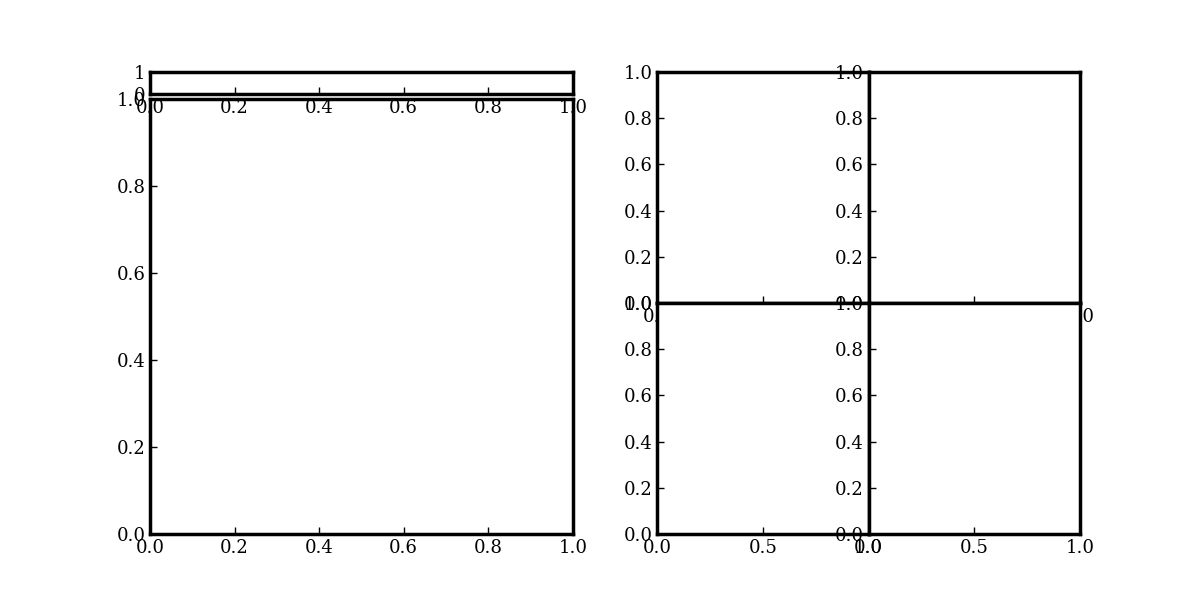

In [51]:
# ============================================================
# Figure initialisation - run next cell to fill
# ============================================================

# fig_beams = plt.figure(figsize=(12,5))
fig_beams = plt.figure(figsize=(12, 6))

# Outer layout: panel A (left) | 2×2 group (right)
gs_outer = gridspec.GridSpec(1, 2, figure=fig_beams, wspace=0.2)

# Panel A
ax_A = fig_beams.add_subplot(gs_outer[0, 0])

# Inner 2×2 grid, tightly packed
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs_outer[0, 1], hspace=0, wspace=0
)
ax_a = fig_beams.add_subplot(gs_inner[0, 0])
ax_b = fig_beams.add_subplot(gs_inner[0, 1])
ax_c = fig_beams.add_subplot(gs_inner[1, 0])
ax_d = fig_beams.add_subplot(gs_inner[1, 1])

axs_beams = {"A": ax_A, "a": ax_a, "b": ax_b, "c": ax_c, "d": ax_d}
## colorbar
div0 = make_axes_locatable(axs_beams["A"])
mapcbarHI = div0.append_axes('top',size='5%',pad=0.05)


In [58]:
# ── Integrated spectra ─────────────────────────────────────────────────────────


# plot reference (Source)
_, velHI_ref, spectrumHI_ref, _, _, _ = map_loader.crop_circle(CoordSource, TRACER, FOV_BEAMS)


for k, (coord, col) in enumerate(zip(CoordsOff, colors)):
    axis = axs_beams[alphabet[k]]
    axis.clear()
    graphics.set_axes(axis)
    
    # Extract HI spectrum at this offset position.
    _, velHI_off, spectrumHI_off, _, _, _ = map_loader.crop_circle(coord, TRACER, FOV_BEAMS)

    axis.plot(velHI_ref, spectrumHI_ref, color="k", ls="--")
    axis.plot(velHI_off, spectrumHI_off, color=col)
    
    # Automatically detect and annotate spectral peaks in [-50, +50] km/s.
    cond_peak = (velHI_off < VMAX_HI) & (velHI_off > VMIN_HI)
    peak_idx_off = find_peaks(spectrumHI_off[cond_peak])[0]

    # Annotation of the peaks
    
    for ikm,km in enumerate(peak_idx_off):
        xm = velHI_off[cond_peak][km]
        ym = spectrumHI_off[cond_peak][km]
        top = (ikm%2)*ym
        axis.vlines(xm, -5, ym, lw=0.7, ls='--',color=col)
        axis.text( xm, top,f"{xm:.0f} km/s",
                      color=col,
                      fontsize=9,
                      ha = 'center',
                      va = 'bottom'
                 )

    axis.set_xlim(VMIN_HI+1, VMAX_HI-1)
    axis.set_ylim(HI_TMIN, HI_TMAX)

ax_a.set_xticks([])
ax_b.set_xticks([])
ax_b.set_yticks([])
ax_d.set_yticks([])



[]

In [50]:
# ── Moment 1 of the whole region ─────────────────────────────────────────────────────────
_, _, _, lon, lat, mom0, mom1 = map_loader.moment1_crop(
        CoordSource, TRACER, (2*SKY_EXTENSION_DEG*u.deg, 2*SKY_EXTENSION_DEG*u.deg),
        v_start=VMIN_HI, v_stop=VMAX_HI,
        shape=SHAPE
    )

ax_A.clear()
graphics.set_axes(axis)
m1 = ax_A.imshow(mom1, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap='jet')#, vmin=0,vmax=10)
graphics.overlay_positions(ax_A, CoordsOff, colors, beam_width=EXTENT_MAX.value)

plt.colorbar(mappable=m1,cax = mapcbarHI, location='top')
mapcbarHI.set_title('Velocity (km/s)', size=15)
ax_A.set_xlim(min(lon),max(lon))
# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
graphics.overlay_source(ax_A,
                        CoordSource,
                        SOURCE_HAS_EXTENT,
                        width=_major_deg, height=_minor_deg,
                        angle=SOURCE_ANGLE_DEG,
                        facecolor=SOURCE_ELLIPSE_FACECOLOR,
                        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
                        linewidth=SOURCE_ELLIPSE_LINEWIDTH
                    )

ValueError: operands could not be broadcast together with shapes (155,120,120) (155,) 

In [ ]:
# Final layout

# Bounding box of the 2×2 block from the axes positions
pos_tl = ax_a.get_position()  # top-left
pos_br = ax_d.get_position()  # bottom-right

x_center = (pos_tl.x0 + pos_br.x1) / 2
y_center = (pos_tl.y1 + pos_br.y0) / 2

fig_beams.text(
    x_center, pos_br.y0 - 0.05,
    "Velocity (km/s)",
    ha="center", va="top",
)
fig_beams.text(
    pos_tl.x0 - 0.05, y_center,
    "Brightness temperature (K)",
    ha="right", va="center", rotation=90,
)

fig_beams.suptitle(f"{TRACER} spectra at offset positions — {SOURCE_NAME}", fontsize=13)
fig_beams.tight_layout()

In [ ]:
OUTNAME = f"ALLBEAMS_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

#### (ii) Second fig
Zoom-in on one pointing. Concentric real simulated NenuFAR beams and corresponding integrated spectra

In [59]:
# ── Configuration and instanciation ─────────────────────────────────────────────────────────

CoordCenter = CoordSource
POINTING_INDEX = 0 # 0 if source, 1,2,3,4 if pointings

FOV_REGION = FOV
DISPLAY = "Moment 1"

HI_TMIN, HI_TMAX =  -5, np.nanmax(SLICEHI)
##### 

cube, vel, _, lon, lat, mom0, mom1 = map_loader.moment1_crop(CoordCenter, 'HI', FOV_REGION, v_start=VMIN_HI,v_stop=VMAX_HI, shape='square')
X,Y = np.meshgrid(lon,lat)

POINTING_BEAM  = EVERYBEAM[POINTING_INDEX]
lon_beam = np.linspace(POINTING_BEAM.center_l[POINTING_INDEX] - POINTING_BEAM.extension,
                       POINTING_BEAM.center_l[POINTING_INDEX] + POINTING_BEAM.extension, POINTING_BEAM.n_grid)
lat_beam = np.linspace(POINTING_BEAM.center_b[POINTING_INDEX] - POINTING_BEAM.extension,
                       POINTING_BEAM.center_b[POINTING_INDEX] + POINTING_BEAM.extension, POINTING_BEAM.n_grid)


ValueError: operands could not be broadcast together with shapes (155,60,60) (155,) 

In [ ]:
fig_beams2 = plt.figure(figsize=(12,6))
mosaic = fig_beams2.subplot_mosaic('''
                                A.abc
                                A.def
                                A.ghi
                                
                                
                                ''', width_ratios=(10,1,3,3,3))

## colorbar
div0 = make_axes_locatable(mosaic["A"])
mapcbarHI = div0.append_axes('top',size='5%',pad=0.05)

In [ ]:
# ── Moment map centred on one pointing ─────────────────────────────────────────────────────

mosaic["A"].clear()

graphics.set_axes(mosaic["A"])

match DISPLAY :
    case "Moment 0" :
        IMAGE = mom0
        COLORMAP = HI_cmap
        CBAR_LABEL = "$T_b$ (K)"
        
    case "Moment 1" :
        IMAGE = mom1
        COLORMAP = "jet"
        CBAR_LABEL = "Velocity (km/s)"
        
img = mosaic["A"].imshow(IMAGE, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap=COLORMAP)
plt.colorbar(mappable=img,cax = mapcbarHI, location='top')
mapcbarHI.set_title(CBAR_LABEL)

# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
graphics.overlay_source(mosaic["A"],
                        CoordSource,
                        SOURCE_HAS_EXTENT,
                        width=_major_deg, height=_minor_deg,
                        angle=SOURCE_ANGLE_DEG,
                        facecolor=SOURCE_ELLIPSE_FACECOLOR,
                        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
                        linewidth=SOURCE_ELLIPSE_LINEWIDTH
                    )
# ── Consecutive beams on map ───────────────────────────────────────────────────────────────
# ── Exact spectra inside the beams ─────────────────────────────────────────────────────────


beam_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(BEAM_FREQUENCIES_MHZ)))

#for fbeam, fwhm_deg, bcol in zip(BEAM_FREQUENCIES_MHZ, BEAM_ANGULAR_RES, beam_colors):
for i,bcol in enumerate(beam_colors):
    # radius = fwhm_deg / 2
    beam_table = POINTING_BEAM[i].values

    # projection on the map to extract the spectra
    regrided_beam = RegularGridInterpolator(points=(lon_beam,lat_beam),values=beam_table, method="linear")((X,Y))
    cube_extract = np.copy(cube)
    cube_extract[:, regrided_beam<np.max(regrided_beam)/2] = np.nan
    spectrum = np.nanmean(cube_extract, axis=(1,2))
    
    mosaic[alphabet[i]].clear()
    graphics.set_axes(mosaic[alphabet[i]])
    # plotting the FWHM of the beam and integrated spectra
    if BEAM_FREQUENCIES_MHZ[i] < F_EXTENT_MAX :
        mosaic["A"].contour(beam_table, extent = (lon_beam[0],lon_beam[-1],lat_beam[0], lat_beam[-1]), 
                            colors=[bcol], levels = [np.max(beam_table)/2], linestyles=['dotted'])
        mosaic[alphabet[i]].plot(vel,spectrum, color=bcol, ls='dotted')
    else :
        mosaic["A"].contour(beam_table, extent = (lon_beam[0],lon_beam[-1],lat_beam[0], lat_beam[-1]), 
                            colors=[bcol], levels = [np.max(beam_table)/2])
        mosaic[alphabet[i]].plot(vel,spectrum, color=bcol)
    
    ### labels
    txtlabel = f"{BEAM_FREQUENCIES_MHZ[i].value: .1f} MHz\n {BEAM_ANGULAR_RES[i]:.2f} °"
    mosaic[alphabet[i]].text(0.05,0.94,txtlabel, transform = mosaic[alphabet[i]].transAxes, va='top', ha='left', fontsize=11)

    mosaic[alphabet[i]].set_xlim(VMIN_HI+1, VMAX_HI-1)
    mosaic[alphabet[i]].set_ylim(HI_TMIN, HI_TMAX)
    
## VISUAL SETTINGS

mosaic["A"].set_xlim(lon[-1], lon[0])
mosaic["A"].set_ylim(lat[0], lat[-1])

mosaic["A"].set_xlabel("Galactic Longitude", size=15)
mosaic["A"].set_ylabel("Galactic Latitude", size=15)

slicealphabet = alphabet[:9]
for letter in slicealphabet[1::3] + slicealphabet[2::3]:
    mosaic[letter].set_yticklabels([])
for letter in slicealphabet[:6]:
    mosaic[letter].set_xticklabels([])

mosaic['h'].set_xlabel("Velocity (km/s)", size=15)
mosaic['d'].set_ylabel("$T_b$ (K)", size=16)

fig_beams2.tight_layout()
fig_beams2.subplots_adjust(wspace=0,hspace=0)

In [ ]:
OUTNAME = f"ZOOMIN_REALBEAM_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

### 5c. HI Interactive Exploration plot
Exploration of the correlation between HI and dust

In [ ]:
# Layout: mosaic with HI spectrum (A), dust profile (C) and moment map (B).
figHI, mosaic = plt.subplot_mosaic(
    '''
    AB
    CB
    ''',
    figsize=(10, 6), width_ratios=(5,6)
)

## colorbar
div0 = make_axes_locatable(mosaic["B"])
mapcbarHI = div0.append_axes('right',size='5%',pad=0.05)


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
# Selection along the dust line of sight (kpc)
RMIN_HI, RMAX_HI = 0.3, 0.3

# Velocity range to highlight in HI spectra [km/s].
VSELECT_MIN, VSELECT_MAX = -7,5

# Pointing selection
CoordCenter = CoordSource

# Type of data
DISPLAY = "Moment 0"
DISPLAY_OFFS = False

# ── Instanciation ─────────────────────────────────────────────────────────
cube, vel, spectrum, lon, lat, mom0_select, mom1_select = map_loader.moment1_crop(CoordCenter, 'HI', FOV, 
                                                                   v_start=VSELECT_MIN, v_stop=VSELECT_MAX,
                                                                   shape='square')
vel_select=vel[(vel>VSELECT_MIN) & (vel<VSELECT_MAX)]
spectrum_select = spectrum[(vel>VSELECT_MIN) & (vel<VSELECT_MAX)]

dust_fov_select = dustmap.extinction_fov(CoordCenter, FOV, delta=DUST_DELTA_DEG, r_min=RMIN_HI, r_max=RMAX_HI, dr=DUST_DR)
dust_los_select = dustmap.extinction_los(CoordCenter, FOV, delta=DUST_DELTA_DEG, r_min=RMIN_HI, r_max=RMAX_HI, dr=DUST_DR)

r_select = np.arange(RMIN_HI, RMAX_HI,DUST_DR)
# ── Visualisation ─────────────────────────────────────────────────────────
# --- Panel A: HI mean spectrum ---
axHI = mosaic['A']
axHI.clear()

axHI.plot(vel, spectrum, c='gray',
          label="Full spectrum")
axHI.plot(vel_select, spectrum_select,
          c=HI_color, label=f"Displayed spectrum\n{VSELECT_MIN} to {VSELECT_MAX} km/s")
axHI.axvline(VSELECT_MIN, 0, spectrum_select[0], color=HI_color, linestyle='dotted')
axHI.axvline(VSELECT_MAX, 0, spectrum_select[-1], color=HI_color, linestyle='dotted')

axHI.set_xlim(VMIN_HI, VMAX_HI)
axHI.set_ylim(HI_TMIN, HI_TMAX)
axHI.set_xlabel("Velocity (km/s)")
axHI.set_ylabel("$T_b$ (K)")
axHI.set_title(f"HI spectrum averaged\nover the NenuFAR beam ({SOURCE_NAME})")
axHI.legend(fontsize=8)
graphics.set_axes(axHI)

# --- Panel C: Dust extinction profile ---
axdust = mosaic['C']
axdust.clear()

axdust.plot(radiitot, EXTINC_source_los,
            c='gray', label=f"Full dust distribution")
axdust.plot(r_select, dust_los_select,
            c='k', label=f"Displayed dust\n{RMIN_HI} to {RMAX_HI} km/s")


axdust.set_xlabel("Distance from the Sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
# axdust.set_ylim(-0.1, 1.1)
axdust.legend(fontsize=8)
graphics.set_axes(axdust)

# --- Panel B: HI moment map + dust contour ---
axmapHI = mosaic['B']
axmapHI.clear()
mapcbarHI.clear()
im = axmapHI.imshow(
    mom0_select,
    extent=(lon[0], lon[-1], lat[0], lat[-1]),
    origin='lower', cmap=HI_cmap
)
plt.colorbar(im, cax=mapcbarHI, label=r'$T_b$ (K)')

# Source position and offset markers.
if DISPLAY_OFFS :
    graphics.overlay_positions(axmapHI,CoordsOff, colors, beam_width=EXTENT_MAX.value)
    
# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
graphics.overlay_source(axmapHI,
        CoordSource,
        SOURCE_HAS_EXTENT,
        width=_major_deg, height=_minor_deg,
        angle=SOURCE_ANGLE_DEG,
        facecolor=SOURCE_ELLIPSE_FACECOLOR,
        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
        linewidth=SOURCE_ELLIPSE_LINEWIDTH)


# Overplot of dust contours 
axmapHI.contour(dust_fov_select, extent =(lon[-1], lon[0], lat[0], lat[-1]), cmap="Grays")

axmapHI.set_xlabel("Galactic Longitude", size=12)
axmapHI.set_ylabel("Galactic Latitude", size=12)
axmapHI.set_title(f"HI moment 0 ({VSELECT_MIN} to {VSELECT_MAX} km/s)")
# axmapHI.legend(fontsize=7)
graphics.set_axes(axmapHI, label_pad=10)

figHI.suptitle(f"HI analysis — {SOURCE_NAME}", fontsize=14)
figHI.tight_layout()

In [ ]:
OUTNAME = f"CLOUD_CORRELATION_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

---
## 6. CO spectral cube — extraction and moment maps

Load the HI 21-cm PPV cube, crop it around the source, compute the mean spectrum
and moment maps, then compare them to the dust profile and NenuFAR beams.

In [ ]:
# ============================================================
# Spatial and spectral analysis parameters - HI
# ============================================================
TRACER = 'CO'
# Velocity range to highlight in HI spectra [km/s].
VMIN_CO, VMAX_CO = -50, 50

# Graphic parameters
CO_color = "blue"
CO_cmap = "Blues"

In [ ]:
# Initialise the map loader for the current source.
# The loader finds the HI and CO FITS cubes by matching SOURCE_NAME
# against the file names in the data directories.
# Adjust path_co and path_hi if your cubes live elsewhere.
map_loader = maps.MapLoader(
    source=SOURCE_NAME.replace(" ", ""),   # e.g. "TauA" — must match FITS file names
    path_co="../maps/COmaps/",
    path_hi="../maps/HImaps/"
)


In [ ]:
# Crop the HI cube to the field of view defined in Section 1.
# Returns:
#   SLICECO      — cropped PPV sub-cube (3-D array)
#   velCO        — velocity axis [km/s]
#   spectrumCO   — mean spectrum over the aperture [K]
#   lonslice_CO  — Galactic longitude axis of the cropped region [deg]
#   latslice_CO  — Galactic latitude axis [deg]
#   mom0_CO      — moment-0 map (integrated intensity) over the full velocity range

SLICECO, velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_CO = \
    map_loader.crop_square(CoordSource, TRACER, FOV)

print(f"CO cube cropped: {SLICECO.shape},  vel range [{velCO.min():.1f}, {velCO.max():.1f}] km/s")

VMIN_CO = max(velCO.min(), VMIN_CO)
VMAX_CO = min(velCO.max(), VMAX_CO)

In [ ]:
# Compute the moment-0 map restricted to the velocity range [VMIN_HI, VMAX_HI].
# This isolates emission likely associated with ISM clouds along the line of sight.

_, velCO_full, spectrumCO_full, lonCO_full, latCO_full, mom0_CO_vel = \
    map_loader.moment0_crop(
        CoordSource, TRACER, FOV,
        v_start=VMIN_CO, v_stop=VMAX_CO,
        shape="square"
    )

# Velocity condition mask — used later for coloured spectrum segments.
condCO = (velCO >= VMIN_CO) & (velCO <= VMAX_CO)


### 6a. Mosaic channel map
Displays CO brightness temperature in 25 velocity channels arranged in a 5×5 grid.  
Each panel covers a $\displaystyle \frac{VMAX\_HI-VMIN\_HI}{N\_PANELS}$ km/s wide velocity slice.  

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

SHAPE     = "square"
EXTEN     = SKY_EXTENSION_DEG        # angular size of each cutout

VMIN_CHAN = VMIN_CO                  # lowest velocity edge (km/s)
VMAX_CHAN = VMAX_CO                  # highest velocity edge (km/s)
N_PANELS  =  25                  # number of panels in the channel map (i.e. resolution of the channel map)

VMIN_NORM = 0                   # colormap minimum (normalised T_b)
VMAX_NORM = np.nanmax(SLICECO)  # colormap maximum (normalised T_b)

SHOW_BEAM   = False            # overlay the beam FWHM circle
SHOW_SOURCE = True
SHOW_OFFPTS = True             # overlay the off-beam pointing

center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

print("Width of the channel map =", (VMAX_CO-VMIN_CO)/N_PANELS, "km/s")

In [ ]:
# ── Figure layout ─────────────────────────────────────────────────────────────
# 5×5 panels (letters a–y) + 1 narrow column (z) for the colorbar

fig_chanCO = plt.figure(figsize=(10.2, 10))
axes_chan = fig_chanCO.subplot_mosaic(
    """
    abcdez
    fghijz
    klmnoz
    pqrstz
    uvwxyz
    """,
    width_ratios=(1, 1, 1, 1, 1, 0.2),
)

In [ ]:
# ── Channel edges ─────────────────────────────────────────────────────────────

chan_edges = np.linspace(VMIN_CHAN, VMAX_CHAN, N_PANELS + 1)  # shape (26,)

# ── Draw one panel per channel ────────────────────────────────────────────────

for i in range(N_PANELS):
    vmin, vmax = chan_edges[i], chan_edges[i + 1]

    # Number of HI spectral pixels falling inside this velocity slice
    # (used to normalise the moment-0 map to a per-channel average)
    

    # Compute the moment-0 map for this slice
    _, _, _, lon, lat, mom0 = map_loader.moment0_crop(
        CoordSource, TRACER, FOV,
        v_start=vmin, v_stop=vmax,
        shape=SHAPE
    )

    # Mask empty pixels so they are transparent
    mom0[mom0 == 0] = np.nan

    # ── Panel ────────────────────────────────────────────────────────────────
    ax = axes_chan[alphabet[i]]
    ax.clear()
    graphics.set_axes(ax)
    mappable = ax.imshow(
        mom0,
        vmin=VMIN_NORM, vmax=VMAX_NORM,
        extent=(lon[0], lon[-1], lat[0], lat[-1]),
        origin="lower",
        cmap=CO_cmap,
    )

    # Target marker
    ax.plot(center_l, center_b, ".", c="k")

    # Velocity range label
    ax.text(
        0.5, 0.1, f"{vmin:.0f} $-$ {vmax:.0f} km/s",
        color="k", transform=ax.transAxes, ha="center", fontsize=10,
    )

    # Beam FWHM circle (dashed) 
    # Here we use the widest beam, approximated to a circle 
    # see later for more accurate beam representation
    if SHOW_BEAM:
        beam_radius = 3.59 / 2  # degrees
        ax.add_patch(Circle(
            xy=(center_l.value, center_b.value),
            radius=beam_radius,
            fill=False,
            linestyle="--",
            edgecolor="k",
            linewidth=1,
        ))

    # Pointing markers
    if SHOW_OFFPTS:
        graphics.overlay_positions(ax, CoordsOff, colors,off_marker='x')
    if SHOW_SOURCE :
        graphics.overlay_source(ax, CoordSource)
        
    # Show axis labels only on the bottom-left panel
    if alphabet[i] == "u":
        ax.set_xlabel("Galactic longitude")
        ax.set_ylabel("Galactic latitude")
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])

# ── Colorbar and title ────────────────────────────────────────────────────────

cbar = fig_chanCO.colorbar(mappable, cax=axes_chan["z"])
cbar.set_label("$T_b$ [K]")

fig_chanCO.suptitle(f"Channel map of {TRACER}")
fig_chanCO.subplots_adjust(hspace=0, wspace=0)

In [ ]:
OUTNAME = f"CHANNEL_MAP_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_chanCO.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

### 6b. Region overview in NenuFAR beams

#### First fig: Spectra integrated in average NenuFAR beams centred on every pointing  

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
SHAPE     = "square"

# Maximal angular resolution <=> minimal frequency of usable data
F_EXTENT_MAX = 19.14 * u.MHz # minimal frequency where stacks reveal detections for Taurus A
EXTENT_MAX   = nenufar_core.angular_resolution(frequency=F_EXTENT_MAX) # average NenuFAR beam size
print(f"Angular resolution of NenuFAR at {F_EXTENT_MAX} = ",EXTENT_MAX)
FOV_BEAMS = (EXTENT_MAX,EXTENT_MAX)

VMIN, VMAX = VMIN_CO, VMAX_CO               # velocity axis limits for HI (km/s)
CO_TMIN, CO_TMAX =  -2, np.nanmax(SLICECO)   # temperature axis limits for HI (K)
# HI_PEAK_VMIN, HI_PEAK_VMAX = -40, 40        # velocity range for peak detection



center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

In [ ]:
### HERE -- CHANGE THE LAYOUT OF THE FIGURE TO ADAPT TO NUMBER OF OFFSETS/SOURCES

# fig_beams = plt.figure(figsize=(12,5))
fig_beams = plt.figure(figsize=(12, 6))

# Outer layout: panel A (left) | 2×2 group (right)
gs_outer = gridspec.GridSpec(1, 2, figure=fig_beams, wspace=0.2)

# Panel A
ax_A = fig_beams.add_subplot(gs_outer[0, 0])

# Inner 2×2 grid, tightly packed
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs_outer[0, 1], hspace=0, wspace=0
)
ax_a = fig_beams.add_subplot(gs_inner[0, 0])
ax_b = fig_beams.add_subplot(gs_inner[0, 1])
ax_c = fig_beams.add_subplot(gs_inner[1, 0])
ax_d = fig_beams.add_subplot(gs_inner[1, 1])

axs_beams = {"A": ax_A, "a": ax_a, "b": ax_b, "c": ax_c, "d": ax_d}
## colorbar
div0 = make_axes_locatable(axs_beams["A"])
mapcbarCO = div0.append_axes('top',size='5%',pad=0.05)


In [ ]:
# ── Integrated spectra ─────────────────────────────────────────────────────────


# plot reference (Source)
_, velCO_ref, spectrumCO_ref, _, _, _ = map_loader.crop_circle(CoordSource, TRACER, FOV_BEAMS)


for k, (coord, col) in enumerate(zip(CoordsOff, colors)):
    axis = axs_beams[alphabet[k]]
    axis.clear()
    graphics.set_axes(axis)
    
    # Extract HI spectrum at this offset position.
    _, velCO_off, spectrumCO_off, _, _, _ = map_loader.crop_circle(coord, TRACER, FOV_BEAMS)

    axis.plot(velCO_ref, spectrumCO_ref, color="k", ls="--")
    axis.plot(velCO_off, spectrumCO_off, color=col)
    
    # Automatically detect and annotate spectral peaks in [-50, +50] km/s.
    cond_peak = (velCO_off < VMAX_CO) & (velCO_off > VMIN_CO)
    if np.nanmax(spectrumCO_off)>3*np.nanstd(spectrumCO_off):
        peak_idx_off = find_peaks(spectrumCO_off[cond_peak],prominence=0.5*np.nanmax(spectrumCO_off))[0]
    else :
        peak_idx_off = []
    # Annotation of the peaks
    
    for ikm,km in enumerate(peak_idx_off):
        xm = velCO_off[cond_peak][km]
        ym = spectrumCO_off[cond_peak][km]
        top = (ikm%2)*ym
        axis.vlines(xm, CO_TMIN, ym, lw=0.7, ls='--',color=col)
        axis.text( xm, top,f"{xm:.0f} km/s",
                      color=col,
                      fontsize=9,
                      ha = 'center',
                      va = 'top'
                 )

    axis.set_xlim(VMIN_CO+1, VMAX_CO-1)
    axis.set_ylim(CO_TMIN/3, CO_TMAX/3)

ax_a.set_xticks([])
ax_b.set_xticks([])
ax_b.set_yticks([])
ax_d.set_yticks([])



In [ ]:
# ── Moment 1 of the whole region ─────────────────────────────────────────────────────────
## HERE ----- CHHANGE valuemin/valuemax to adapt the color scale to your case
valuemin = 2
valuemax = 7
_, _, _, lon, lat, mom0, mom1 = map_loader.moment1_crop(
        CoordSource, TRACER, (2*SKY_EXTENSION_DEG*u.deg, 2*SKY_EXTENSION_DEG*u.deg),
        v_start=VMIN_CO, v_stop=VMAX_CO,
        shape=SHAPE
    )
mom1[mom0<0.01*CO_TMAX] = np.nan
ax_A.clear()
graphics.set_axes(axis)
m1 = ax_A.imshow(mom1, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap='jet', vmin=valuemin,vmax=valuemax)
graphics.overlay_positions(ax_A, CoordsOff, colors, beam_width=EXTENT_MAX.value)

plt.colorbar(mappable=m1,cax = mapcbarCO, location='top')
mapcbarCO.set_title('Velocity (km/s)', size=15)
ax_A.set_xlim(min(lon),max(lon))
# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
graphics.overlay_source(ax_A,
                        CoordSource,
                        SOURCE_HAS_EXTENT,
                        width=_major_deg, height=_minor_deg,
                        angle=SOURCE_ANGLE_DEG,
                        facecolor=SOURCE_ELLIPSE_FACECOLOR,
                        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
                        linewidth=SOURCE_ELLIPSE_LINEWIDTH
                    )

In [ ]:
# Final layout

# Bounding box of the 2×2 block from the axes positions
pos_tl = ax_a.get_position()  # top-left
pos_br = ax_d.get_position()  # bottom-right

x_center = (pos_tl.x0 + pos_br.x1) / 2
y_center = (pos_tl.y1 + pos_br.y0) / 2

fig_beams.text(
    x_center, pos_br.y0 - 0.05,
    "Velocity (km/s)",
    ha="center", va="top",
)
fig_beams.text(
    pos_tl.x0 - 0.05, y_center,
    "Brightness temperature (K)",
    ha="right", va="center", rotation=90,
)

fig_beams.suptitle(f"{TRACER} spectra at offset positions — {SOURCE_NAME}", fontsize=13)
fig_beams.tight_layout()

In [ ]:
OUTNAME = f"ALLBEAMS_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

#### (ii) Second fig
Zoom-in on one pointing. Concentric real simulated NenuFAR beams and corresponding integrated spectra

In [ ]:
# ── Configuration and instanciation ─────────────────────────────────────────────────────────

CoordCenter = CoordsOff[1]
POINTING_INDEX = 2 # 0 if source, 1,2,3,4 if pointings

FOV_REGION = FOV
DISPLAY = "Moment 1"

CO_TMIN, CO_TMAX =  -2, np.nanmax(SLICECO)
##### 

cube, vel, _, lon, lat, mom0,mom1 = map_loader.moment1_crop(CoordCenter, TRACER, FOV_REGION, v_start=VMIN_CO,v_stop=VMAX_CO, shape='square')
X,Y = np.meshgrid(lon,lat)

POINTING_BEAM  = EVERYBEAM[POINTING_INDEX]
lon_beam = np.linspace(POINTING_BEAM.center_l[POINTING_INDEX] - POINTING_BEAM.extension,
                       POINTING_BEAM.center_l[POINTING_INDEX] + POINTING_BEAM.extension, POINTING_BEAM.n_grid)
lat_beam = np.linspace(POINTING_BEAM.center_b[POINTING_INDEX] - POINTING_BEAM.extension,
                       POINTING_BEAM.center_b[POINTING_INDEX] + POINTING_BEAM.extension, POINTING_BEAM.n_grid)


## HERE ----- CHHANGE valuemin/valuemax to adapt the color scale to your case
valuemin = 2
valuemax = 7

In [ ]:
fig_beams2 = plt.figure(figsize=(12,6))
mosaic = fig_beams2.subplot_mosaic('''
                                A.abc
                                A.def
                                A.ghi
                                
                                
                                ''', width_ratios=(10,1,3,3,3))

## colorbar
div0 = make_axes_locatable(mosaic["A"])
mapcbarCO = div0.append_axes('top',size='5%',pad=0.05)

In [ ]:
# ── Moment map centred on one pointing ─────────────────────────────────────────────────────

mosaic["A"].clear()

graphics.set_axes(mosaic["A"])

match DISPLAY :
    case "Moment 0" :
        IMAGE = mom0
        COLORMAP = HI_cmap
        CBAR_LABEL = "$T_b$ (K)"
        
    case "Moment 1" :
        mom1[mom0<0.01*CO_TMAX] = np.nan
        IMAGE = mom1
        COLORMAP = "jet"
        CBAR_LABEL = "Velocity (km/s)"
        
img = mosaic["A"].imshow(IMAGE, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap=COLORMAP,vmin=valuemin, vmax=valuemax)
plt.colorbar(mappable=img,cax = mapcbarCO, location='top')
mapcbarHI.set_title(CBAR_LABEL)

# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
graphics.overlay_source(mosaic["A"],
                        CoordSource,
                        SOURCE_HAS_EXTENT,
                        width=_major_deg, height=_minor_deg,
                        angle=SOURCE_ANGLE_DEG,
                        facecolor=SOURCE_ELLIPSE_FACECOLOR,
                        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
                        linewidth=SOURCE_ELLIPSE_LINEWIDTH
                    )
# ── Consecutive beams on map ───────────────────────────────────────────────────────────────
# ── Exact spectra inside the beams ─────────────────────────────────────────────────────────


beam_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(BEAM_FREQUENCIES_MHZ)))

#for fbeam, fwhm_deg, bcol in zip(BEAM_FREQUENCIES_MHZ, BEAM_ANGULAR_RES, beam_colors):
for i,bcol in enumerate(beam_colors):
    # radius = fwhm_deg / 2
    beam_table = POINTING_BEAM[i].values

    # projection on the map to extract the spectra
    regrided_beam = RegularGridInterpolator(points=(lon_beam,lat_beam),values=beam_table, method="linear")((X,Y))
    cube_extract = np.copy(cube)
    cube_extract[regrided_beam<np.max(regrided_beam)/2,:] = np.nan
    spectrum = np.nanmean(cube_extract, axis=(0,1))
    
    mosaic[alphabet[i]].clear()
    graphics.set_axes(mosaic[alphabet[i]])
    # plotting the FWHM of the beam and integrated spectra
    if BEAM_FREQUENCIES_MHZ[i] < F_EXTENT_MAX :
        mosaic["A"].contour(beam_table, extent = (lon_beam[0],lon_beam[-1],lat_beam[0], lat_beam[-1]), 
                            colors=[bcol], levels = [np.max(beam_table)/2], linestyles=['dotted'])
        mosaic[alphabet[i]].plot(vel,spectrum, color=bcol, ls='dotted')
    else :
        mosaic["A"].contour(beam_table, extent = (lon_beam[0],lon_beam[-1],lat_beam[0], lat_beam[-1]), 
                            colors=[bcol], levels = [np.max(beam_table)/2])
        mosaic[alphabet[i]].plot(vel,spectrum, color=bcol)
    
    ### labels
    txtlabel = f"{BEAM_FREQUENCIES_MHZ[i].value: .1f} MHz\n {BEAM_ANGULAR_RES[i]:.2f} °"
    mosaic[alphabet[i]].text(0.05,0.94,txtlabel, transform = mosaic[alphabet[i]].transAxes, va='top', ha='left', fontsize=11)

    mosaic[alphabet[i]].set_xlim(VMIN_CO+1, VMAX_CO-1)
    mosaic[alphabet[i]].set_ylim(CO_TMIN, CO_TMAX)
    
## VISUAL SETTINGS

mosaic["A"].set_xlim(lon[-1], lon[0])
mosaic["A"].set_ylim(lat[0], lat[-1])

mosaic["A"].set_xlabel("Galactic Longitude", size=15)
mosaic["A"].set_ylabel("Galactic Latitude", size=15)

slicealphabet = alphabet[:9]
for letter in slicealphabet[1::3] + slicealphabet[2::3]:
    mosaic[letter].set_yticklabels([])
for letter in slicealphabet[:6]:
    mosaic[letter].set_xticklabels([])

mosaic['h'].set_xlabel("Velocity (km/s)", size=15)
mosaic['d'].set_ylabel("$T_b$ (K)", size=16)

fig_beams2.tight_layout()
fig_beams2.subplots_adjust(wspace=0,hspace=0)

In [ ]:
OUTNAME = f"ZOOMIN_REALBEAM_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

---
## 7. Velocity-to-distance conversion (Reid+2019 rotation curve)

Convert the HI and CO spectral peak velocities to heliocentric distances
using the Galactic rotation model of Reid et al. (2019).
This allows a direct comparison of spectral features with the dust extinction
peaks found in Section 4.

In [ ]:
# Compute the LSR velocity as a function of heliocentric distance in a beam.
# Provides a 3D grid of v_lsr

n_res_r = (DUST_R_MAX-DUST_R_MIN)/DUST_DR
n_res_angle = 40

CoordCenter = CoordSource # HERE -- change to an offset if you want

r_kpc = np.arange(DUST_R_MIN, DUST_R_MAX, DUST_DR)   # shape (n_radii,)

# build a cube of vlsr
glong_min = CoordCenter.galactic.l.value - SKY_EXTENSION_DEG
glong_max = CoordCenter.galactic.l.value + SKY_EXTENSION_DEG
glong_array = np.linspace(glong_min, glong_max, n_res_angle)

glat_min = CoordCenter.galactic.b.value - SKY_EXTENSION_DEG
glat_max = CoordCenter.galactic.b.value + SKY_EXTENSION_DEG
glat_array = np.linspace(glat_min, glat_max, n_res_angle)

### 3D meshgrid

r_, lon_, lat_ = np.meshgrid(r_kpc, glong_array, glat_array, indexing="ij")

vlsr_model = reid19_rotcurve.calc_vlsr(
    glong=lon_,
    glat=lat_,
    dist=r_,
)


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

VISO        = np.arange(int(np.nanmin(vlsr_model)), int(np.nanmax(vlsr_model)), 1)
OPACITY     = 0.3

# ── Build figure ──────────────────────────────────────────────────────────────

fig = go.Figure()

vmin, vmax = np.nanmin(vlsr_model), np.nanmax(vlsr_model)

for v_iso in VISO:
    if not (vmin < v_iso < vmax):
        continue

    verts, faces, _, _ = marching_cubes(vlsr_model, level=v_iso)

    verts_r   = r_kpc[0]       + verts[:, 0] * DUST_DR
    verts_lon = glong_array[0] + verts[:, 1] * (glong_array[1] - glong_array[0])
    verts_lat = glat_array[0]  + verts[:, 2] * (glat_array[1]  - glat_array[0])

    # Convert to standard Galactic Cartesian (pc), Sun at origin
    vx, vy, vz = tools.galactic_to_cartesian(verts_r, verts_lon, verts_lat, 0, 0)

    norm_color = (v_iso - min(VISO)) / (max(VISO) - min(VISO))

    fig.add_trace(go.Mesh3d(
        x=vx*1e3, y=vy*1e3, z=vz*1e3,
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        opacity=OPACITY,
        color=f"hsl({int(norm_color * 240)}, 80%, 55%)",
        name=f"{v_iso} km/s",
        showlegend=True,
    ))

fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=6, color='yellow', symbol='circle'),
    name='Sun',
))

fig.update_layout(
    title="LSR iso-velocity surfaces",
    legend_title="v_LSR (km/s)",
    scene=dict(
        xaxis=dict(title="Galactic X (pc)"),
        yaxis=dict(title="Galactic Y (pc)"),
        zaxis=dict(title="Galactic Z (pc)"),
        aspectmode="data",
    ),
)
fig.show()

In [ ]:
fig = go.Figure()

# ── Dust isosurface ───────────────────────────────────────────────────────────
threshold = np.max(values) / 100
print(f"Isosurface threshold: {threshold:.5g}")

verts, faces, normals, vals = measure.marching_cubes(
    values,
    level=threshold,
    spacing=(dx, dy, dz)
)
verts[:, 0] += x0
verts[:, 1] += y0
verts[:, 2] += z0

fig.add_trace(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    opacity=0.4,
    color="lightgray",
    name="Dust isosurface",
    showlegend=True,
))

# ── LSR iso-velocity surfaces (standard Galactic Cartesian) ───────────────────
for v_iso in VISO:
    if not (vmin < v_iso < vmax):
        continue

    verts_v, faces_v, _, _ = marching_cubes(vlsr_model, level=v_iso)

    verts_r   = r_kpc[0]       + verts_v[:, 0] * DUST_DR
    verts_lon = glong_array[0] + verts_v[:, 1] * (glong_array[1] - glong_array[0])
    verts_lat = glat_array[0]  + verts_v[:, 2] * (glat_array[1]  - glat_array[0])

    vx, vy, vz = tools.galactic_to_cartesian(verts_r, verts_lon, verts_lat, 0, 0)

    norm_color = (v_iso - min(VISO)) / (max(VISO) - min(VISO))

    fig.add_trace(go.Mesh3d(
        x=vx*1e3, y=vy*1e3, z=vz*1e3,
        i=faces_v[:, 0], j=faces_v[:, 1], k=faces_v[:, 2],
        opacity=0.2,
        color=f"hsl({int(norm_color * 240)}, 100%, 55%)",
        name=f"v_LSR = {v_iso} km/s",
        showlegend=True,
    ))

# ── Lines of sight (standard Galactic Cartesian) ──────────────────────────────
if SOURCE_HAS_OFFS:
    for i, off in enumerate(OFFSETS_GAL):
        xc, yc, zc = tools.galactic_to_cartesian(SOURCE_DISTANCE_PC/1e3, off[0], off[1], 0, 0)
        fig.add_trace(go.Scatter3d(
            x=[0, xc*1e3], y=[0, yc*1e3], z=[0, zc*1e3],
            mode="lines",
            line=dict(color=colors[i], dash="dot", width=3),
            name=f"off_{i+1}",
        ))

xc, yc, zc = tools.galactic_to_cartesian(SOURCE_DISTANCE_PC/1e3, source_l.value, source_b.value, 0, 0)
fig.add_trace(go.Scatter3d(
    x=[0, xc*1e3], y=[0, yc*1e3], z=[0, zc*1e3],
    mode="lines",
    line=dict(color="black", dash="dash", width=3),
    name=SOURCE_NAME,
))

fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=6, color='yellow', symbol='circle'),
    name='Sun',
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    title=f"Dust & LSR iso-velocities towards {SOURCE_NAME}",
    scene=dict(
        xaxis=dict(title="Galactic X (pc)"),
        yaxis=dict(title="Galactic Y (pc)"),
        zaxis=dict(title="Galactic Z (pc)"),
        aspectmode="data",
    ),
    legend=dict(font=dict(size=10)),
)
fig.show()

---
## 8. Galactic plane projection — dust, beam & iso-velocities

Top-down (XY) view of the galactic plane: dust density (max-projected along Z),
NenuFAR beam cone, and LSR iso-velocity contours from the Reid+2019 model.

In [ ]:
# ── Wide velocity grid for the full galactic plane ───────────────────────────
# Recompute vlsr on a full-sky (l: 0–360°) grid at b=0, same r as dust.
_r_wide   = np.arange(DUST_R_MIN, DUST_R_MAX, DUST_DR)          # kpc
_l_wide   = np.linspace(0, 360, 360, endpoint=False)            # deg, full circle
_r2d, _l2d = np.meshgrid(_r_wide, _l_wide, indexing='ij')       # (n_r, n_l)
vlsr_wide = reid19_rotcurve.calc_vlsr(glong=_l2d, glat=np.zeros_like(_l2d), dist=_r2d)

# Convert (r, l) at b=0 to Galactic Cartesian (pc)
_x2d = _r2d * 1e3 * np.cos(np.radians(_l2d))
_y2d = _r2d * 1e3 * np.sin(np.radians(_l2d))

# ── Figure ───────────────────────────────────────────────────────────────────
fig_gal, ax = plt.subplots(figsize=(9, 9))

## colorbar
div0 = make_axes_locatable(ax)
mapcbar = div0.append_axes('right',size='5%',pad=0.05)


In [ ]:
ax.clear()
mapcbar.clear()

# boundaries of the map
xbounds = (0, 2000)
ybounds = (0, 2000)

delta_vlsr = 2 # in km/s

# ── Dust: max projection along Z onto the galactic plane ─────────────────────
dust_proj = np.sum(values, axis=2)   # shape (nx, ny)
pcm = ax.pcolormesh(x_arr, y_arr, dust_proj.T,
                    cmap='Greys', shading='auto', alpha=0.8)
# ax.contour(x_arr,y_arr, dust_proj.T)
plt.colorbar(pcm, cax=mapcbar, label="Dust density (lin scale, sum along Z)")

# ── Iso-velocity contours over the full galactic plane ───────────────────────
v_levels = np.arange(int(np.nanmin(vlsr_wide)), int(np.nanmax(vlsr_wide)) + 1, delta_vlsr)
cs = ax.contour(_x2d, _y2d, vlsr_wide, levels=v_levels, cmap='RdBu_r', alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.1f km/s')

# ── NenuFAR beam cone boundary ────────────────────────────────────────────────
r_range = np.linspace(0, SOURCE_DISTANCE_PC, 300)
cos_b_src = np.cos(np.radians(source_b.value))
l_lo, l_hi = source_l.value - SKY_EXTENSION_DEG, source_l.value + SKY_EXTENSION_DEG
for l_edge in [l_lo, l_hi]:
    xe = r_range * cos_b_src * np.cos(np.radians(l_edge))
    ye = r_range * cos_b_src * np.sin(np.radians(l_edge))
    ax.plot(xe, ye, 'k--', lw=1)
x_fill = np.concatenate([r_range * cos_b_src * np.cos(np.radians(l_lo)),
                          r_range[::-1] * cos_b_src * np.cos(np.radians(l_hi))])
y_fill = np.concatenate([r_range * cos_b_src * np.sin(np.radians(l_lo)),
                          r_range[::-1] * cos_b_src * np.sin(np.radians(l_hi))])
ax.fill(x_fill, y_fill, alpha=0.08, color='lightgray', label=f'Beam (±{SKY_EXTENSION_DEG}°)')


# ── Sun ───────────────────────────────────────────────────────────────────────
ax.scatter([0], [0], c='yellow', edgecolors='black', s=120, zorder=5, label='Sun')

# ── Source ────────────────────────────────────────────────────────────────────
if np.isfinite(SOURCE_DISTANCE_REAL_PC):
    xc_src = SOURCE_DISTANCE_PC * cos_b_src * np.cos(np.radians(source_l.value))
    yc_src = SOURCE_DISTANCE_PC * cos_b_src * np.sin(np.radians(source_l.value))
    ax.scatter([xc_src], [yc_src], c='red', s=80, zorder=5, label=SOURCE_NAME)
    ax.annotate(SOURCE_NAME, (xc_src, yc_src), textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlim(xbounds)
ax.set_ylim(ybounds)

ax.set_xlabel("Galactic X (pc)")
ax.set_ylabel("Galactic Y (pc)")
ax.set_title(f"Galactic plane projection towards {SOURCE_NAME}")
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=9)
fig_gal.tight_layout()
